In [1]:
!pip install albumentations --quiet


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import numpy as np
from PIL import Image
import os
import datetime

import matplotlib.pyplot as plt
import seaborn as sns

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    jaccard_score, accuracy_score,
    confusion_matrix, classification_report
)

# Model architecture summary
from torchsummary import summary

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" All libraries imported.")
print(f"  Device : {device}")
if torch.cuda.is_available():
    print(f" GPU    : {torch.cuda.get_device_name(0)}")


 All libraries imported.
  Device : cuda
 GPU    : Tesla P100-PCIE-16GB


In [3]:

# ════════════════════════════════════════════════════════════════
# U-NET ARCHITECTURE (FINAL CLEAN VERSION)
# ════════════════════════════════════════════════════════════════
#
# Based on:
# U-Net: Convolutional Networks for Biomedical Image Segmentation
# (Ronneberger et al., 2015)
#
# Architecture Overview:
#   Encoder  : 4 Downsampling Blocks (Double Conv + MaxPool)
#   Bottleneck: Deepest representation (512 channels)
#   Decoder  : 3 Upsampling Blocks (Bilinear Upsample + Skip Connection)
#   Output   : 1x1 Conv → Single-channel logit map
#
# NOTE:
#   - No Sigmoid in forward().
#   - We use BCEWithLogitsLoss / Dice+BCE which internally
#     applies sigmoid for numerical stability.
# ════════════════════════════════════════════════════════════════

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super(UNet, self).__init__()

        # ────────────────────────────────────────────────────────
        # Double Convolution Block (Conv → BN → ReLU × 2)
        # ────────────────────────────────────────────────────────
        def double_conv(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        # ────────────────────────────────────────────────────────
        # Encoder (Downsampling Path)
        # ────────────────────────────────────────────────────────
        self.enc1 = double_conv(n_channels, 64)
        self.enc2 = double_conv(64, 128)
        self.enc3 = double_conv(128, 256)
        self.enc4 = double_conv(256, 512)  # Bottleneck

        self.pool = nn.MaxPool2d(2)

        # ────────────────────────────────────────────────────────
        # Decoder (Upsampling Path)
        # ────────────────────────────────────────────────────────
        self.upsample = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=True
        )

        self.dec3 = double_conv(512 + 256, 256)
        self.dec2 = double_conv(256 + 128, 128)
        self.dec1 = double_conv(128 + 64, 64)

        # Final 1×1 Convolution → Raw Logits
        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)

        # Optional: Initialize weights
        self._initialize_weights()

    # ────────────────────────────────────────────────────────────
    # Forward Pass
    # ────────────────────────────────────────────────────────────
    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)                 # 256×256 → 64
        e2 = self.enc2(self.pool(e1))     # 128×128 → 128
        e3 = self.enc3(self.pool(e2))     # 64×64   → 256
        e4 = self.enc4(self.pool(e3))     # 32×32   → 512

        # Decoder
        d3 = self.upsample(e4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.upsample(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.upsample(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)  # Raw logits

    # ────────────────────────────────────────────────────────────
    # Weight Initialization (Kaiming for ReLU)
    # ────────────────────────────────────────────────────────────
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

print(" UNet architecture defined successfully.")


 UNet architecture defined successfully.


In [4]:

# Instantiate a temporary model just to print summary
_model_check = UNet(n_channels=3, n_classes=1).to(device)
summary(_model_check, input_size=(3, 256, 256))
del _model_check  # free memory — real model created later

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,792
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              ReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,928
       BatchNorm2d-5         [-1, 64, 256, 256]             128
              ReLU-6         [-1, 64, 256, 256]               0
         MaxPool2d-7         [-1, 64, 128, 128]               0
            Conv2d-8        [-1, 128, 128, 128]          73,856
       BatchNorm2d-9        [-1, 128, 128, 128]             256
             ReLU-10        [-1, 128, 128, 128]               0
           Conv2d-11        [-1, 128, 128, 128]         147,584
      BatchNorm2d-12        [-1, 128, 128, 128]             256
             ReLU-13        [-1, 128, 128, 128]               0
        MaxPool2d-14          [-1, 128,

In [6]:

# ════════════════════════════════════════════════════════════════
# DATA AUGMENTATION (UPDATED CLEAN VERSION)
# ════════════════════════════════════════════════════════════════

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# ───────────────── TRAIN TRANSFORMS ─────────────────
train_transform = A.Compose([
    A.Resize(256, 256),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),

    A.RandomBrightnessContrast(p=0.3),

    # Updated ElasticTransform (no deprecated params)
    A.ElasticTransform(
        alpha=1,
        sigma=50,
        p=0.2
    ),

    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# ───────────────── VALIDATION TRANSFORMS ─────────────────
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

print(" Train and Validation transforms defined correctly ")

 Train and Validation transforms defined correctly 


In [7]:
# ════════════════════════════════════════════════════════════════
# POLYP DATASET CLASS (FINAL PROFESSIONAL VERSION)
# ════════════════════════════════════════════════════════════════

class PolypDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

        # Load only valid image files
        self.images = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name  = self.images[idx]
        img_path  = os.path.join(self.img_dir,  img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found for {img_name}")

        # Load image and mask
        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"))

        # Apply synchronized augmentation
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"]

        # Ensure mask shape = [1, H, W]
        mask = mask.unsqueeze(0).float()
        mask = (mask > 0).float()

        return image, mask

print(" PolypDataset class defined successfully.")


 PolypDataset class defined successfully.


In [8]:

# ════════════════════════════════════════════════════════════════
# DATASET SPLIT (FINAL SAFE VERSION)
# ════════════════════════════════════════════════════════════════

IMAGE_DIR = "/kaggle/input/colorectal-polyp-segmentation-dataset/polyp_dataset/images"
MASK_DIR  = "/kaggle/input/colorectal-polyp-segmentation-dataset/polyp_dataset/masks"

# Create temporary dataset just to get accurate length
temp_dataset = PolypDataset(IMAGE_DIR, MASK_DIR)
total_size = len(temp_dataset)

train_size = int(0.8 * total_size)
val_size   = total_size - train_size

# Reproducible split (does NOT affect global seed)
generator = torch.Generator().manual_seed(42)

train_indices, val_indices = torch.utils.data.random_split(
    range(total_size),
    [train_size, val_size],
    generator=generator
)

train_indices = list(train_indices)
val_indices   = list(val_indices)

# Create separate dataset objects (CRITICAL FIX)
train_full = PolypDataset(IMAGE_DIR, MASK_DIR, transform=train_transform)
val_full   = PolypDataset(IMAGE_DIR, MASK_DIR, transform=val_transform)

train_dataset = Subset(train_full, train_indices)
val_dataset   = Subset(val_full,   val_indices)

# DataLoaders (safe settings for Kaggle)
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(" Dataset split complete.")
print(f"   Total samples      : {total_size}")
print(f"   Training samples   : {len(train_dataset)}")
print(f"   Validation samples : {len(val_dataset)}")
print(f"   Batch size         : {BATCH_SIZE}")
print(f"   Train batches      : {len(train_loader)}")
print(f"   Val batches        : {len(val_loader)}")


 Dataset split complete.
   Total samples      : 1000
   Training samples   : 800
   Validation samples : 200
   Batch size         : 8
   Train batches      : 100
   Val batches        : 25


In [9]:
# ════════════════════════════════════════════════════════════════
# LOSS FUNCTION — Dice + Weighted BCE (FINAL SAFE VERSION)
# ════════════════════════════════════════════════════════════════

class DiceLoss(nn.Module):
    """
    Dice Loss computed per batch element, then averaged.
    Prevents batch-size bias and improves stability.
    """
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)

        # Flatten per batch sample
        preds   = preds.view(preds.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (preds * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            preds.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )

        return 1.0 - dice.mean()


class DiceBCELoss(nn.Module):
    """
    Combined Dice + Weighted BCE loss for imbalanced segmentation.
    """
    def __init__(self, pos_weight=3.0):
        super().__init__()
        self.dice = DiceLoss()

        # Register pos_weight as buffer (device-safe)
        self.register_buffer(
            "pos_weight",
            torch.tensor([pos_weight], dtype=torch.float)
        )

        self.bce = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

    def forward(self, preds, targets):
        dice_loss = self.dice(preds, targets)
        bce_loss  = self.bce(preds, targets)

        return 0.8 * dice_loss + 0.2 * bce_loss


criterion = DiceBCELoss(pos_weight=3.0).to(device)

print(" Dice + Weighted BCE Loss defined (pos_weight=3.0).")


 Dice + Weighted BCE Loss defined (pos_weight=3.0).


In [10]:
# ════════════════════════════════════════════════════════════════
# MODEL INITIALIZATION (CLEAN VERSION)
# ════════════════════════════════════════════════════════════════

MODEL_SAVE_PATH = "/kaggle/working/unet_final_model_1.pth"

# Initialize model
model = UNet(n_channels=3, n_classes=1).to(device)

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Model initialized successfully.")
print(f"Total parameters   : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params   : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Initial LR         : {optimizer.param_groups[0]['lr']}")


Model initialized successfully.
Total parameters   : 7,788,545
Trainable params   : 7,788,545
Initial LR         : 0.0001


In [11]:
TRAIN_MODEL = True    # False- Change to True ONLY when retraining is needed

MODEL_SAVE_PATH = "/kaggle/working/unet_seg_final_model_1.pth"
NUM_EPOCHS = 25

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float("inf")

if TRAIN_MODEL:

    print(" Starting training...\n")

    for epoch in range(NUM_EPOCHS):

        # ───────── TRAIN ─────────
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == masks).sum().item()
            total += masks.numel()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc  = 100.0 * correct / total

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # ───────── VALIDATION ─────────
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, masks)

                val_loss_sum += loss.item() * imgs.size(0)

                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == masks).sum().item()
                val_total += masks.numel()

        val_loss = val_loss_sum / len(val_loader.dataset)
        val_acc  = 100.0 * val_correct / val_total

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(" BEST MODEL SAVED")

        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
        print(f"Train → Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
        print(f"Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")
        print("-" * 50)

    print("\n Training complete.")
    print(f" Model saved at: {MODEL_SAVE_PATH}")

else:
    print(" Training skipped (TRAIN_MODEL=False)")

 Starting training...

 BEST MODEL SAVED
Epoch [1/25]
Train → Loss: 0.6709 | Acc: 69.59%
Val   → Loss: 0.6092 | Acc: 74.00%
--------------------------------------------------
 BEST MODEL SAVED
Epoch [2/25]
Train → Loss: 0.6159 | Acc: 76.75%
Val   → Loss: 0.5854 | Acc: 75.52%
--------------------------------------------------
 BEST MODEL SAVED
Epoch [3/25]
Train → Loss: 0.5882 | Acc: 80.06%
Val   → Loss: 0.5693 | Acc: 82.08%
--------------------------------------------------
 BEST MODEL SAVED
Epoch [4/25]
Train → Loss: 0.5641 | Acc: 81.78%
Val   → Loss: 0.5436 | Acc: 83.22%
--------------------------------------------------
Epoch [5/25]
Train → Loss: 0.5426 | Acc: 83.25%
Val   → Loss: 0.5641 | Acc: 76.08%
--------------------------------------------------
 BEST MODEL SAVED
Epoch [6/25]
Train → Loss: 0.5268 | Acc: 84.55%
Val   → Loss: 0.5033 | Acc: 83.68%
--------------------------------------------------
 BEST MODEL SAVED
Epoch [7/25]
Train → Loss: 0.5007 | Acc: 85.85%
Val   → Loss: 0.4

In [14]:
# ════════════════════════════════════════════════════════════════
# LOAD BEST TRAINED MODEL (FINAL CONSISTENT VERSION)
# ════════════════════════════════════════════════════════════════

MODEL_PATH = "/kaggle/working/unet_seg_final_model_1.pth"

# if not os.path.exists(MODEL_PATH):
#     raise FileNotFoundError(
#         f"Model not found at: {MODEL_PATH}\n"
#         "1. Train and Save Version\n"
#         "2. Create Dataset from Output\n"
#         "3. Add dataset to notebook"
#     )

# Recreate architecture first
model = UNet(n_channels=3, n_classes=1).to(device)

# Then load weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("Best model loaded successfully.")
print(f"Path: {MODEL_PATH}")


Best model loaded successfully.
Path: /kaggle/working/unet_seg_final_model_1.pth


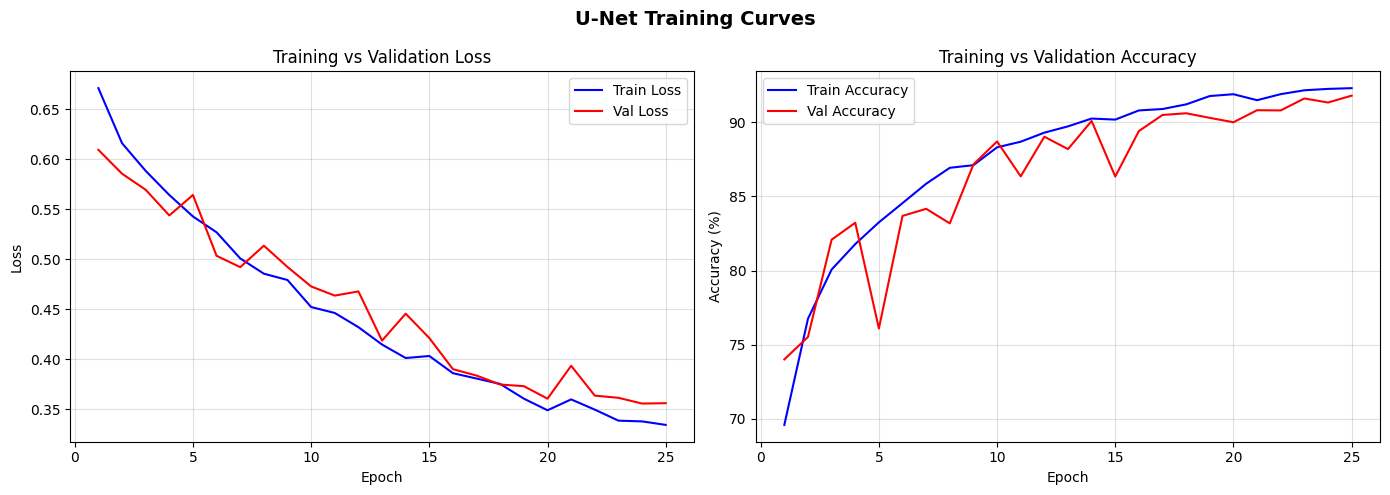

Training curves saved to training_curves.png


In [15]:
# ════════════════════════════════════════════════════════════════
# TRAINING CURVES (UPDATED CLEAN VERSION - NO DOTS)
# ════════════════════════════════════════════════════════════════

if len(train_losses) > 0:

    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curve
    axes[0].plot(epochs, train_losses, "b-", label="Train Loss")
    axes[0].plot(epochs, val_losses,   "r-", label="Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training vs Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)

    # Accuracy curve
    axes[1].plot(epochs, train_accs, "b-", label="Train Accuracy")
    axes[1].plot(epochs, val_accs,   "r-", label="Val Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Training vs Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    plt.suptitle("U-Net Training Curves", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Training curves saved to training_curves.png")

else:
    print("Training curves unavailable (model loaded without retraining).")

In [16]:

# ════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS (FINAL REFINED VERSION)
# ════════════════════════════════════════════════════════════════

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3)

def denormalize(tensor):
    """
    Reverse A.Normalize() for correct matplotlib display.
    """
    img = tensor.cpu().permute(1, 2, 0)  # [C,H,W] → [H,W,C]
    img = img * STD + MEAN
    return img.clamp(0, 1).numpy()


def get_all_preds_targets(model, loader):
    """
    Run model over dataloader and return flattened numpy arrays.
    """
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)
            preds   = (torch.sigmoid(outputs) > 0.5).float()

            all_preds.append(preds.cpu().reshape(-1))
            all_targets.append(masks.cpu().reshape(-1))

    preds_np   = torch.cat(all_preds).numpy().astype(np.uint8)
    targets_np = torch.cat(all_targets).numpy().astype(np.uint8)

    return preds_np, targets_np


print(" Helper functions ready: denormalize(), get_all_preds_targets()")


 Helper functions ready: denormalize(), get_all_preds_targets()


In [17]:
# ════════════════════════════════════════════════════════════════
# SEGMENTATION METRICS (FINAL CLEAN VERSION)
# ════════════════════════════════════════════════════════════════

val_preds, val_targets = get_all_preds_targets(model, val_loader)

precision = precision_score(val_targets, val_preds, zero_division=0)
recall    = recall_score(val_targets, val_preds, zero_division=0)
f1        = f1_score(val_targets, val_preds, zero_division=0)
iou       = jaccard_score(val_targets, val_preds, average="binary", zero_division=0)
acc       = accuracy_score(val_targets, val_preds)

print("=" * 50)
print("   SEGMENTATION METRICS  (Validation Set)")
print("=" * 50)
print(f"   Precision  : {precision:.4f}")
print(f"   Recall     : {recall:.4f} ")
print(f"   F1-Score   : {f1:.4f}")
print(f"   IoU        : {iou:.4f}")
print(f"   Accuracy   : {acc:.4f}")
print("=" * 50)



   SEGMENTATION METRICS  (Validation Set)
   Precision  : 0.7678
   Recall     : 0.7176 
   F1-Score   : 0.7419
   IoU        : 0.5896
   Accuracy   : 0.9133


In [40]:

# ════════════════════════════════════════════════════════════════
# CLASSIFICATION REPORT
# ════════════════════════════════════════════════════════════════
# Shows per-class precision, recall, F1 for both Background
# and Polyp classes. Useful for seeing class-level performance.
# ════════════════════════════════════════════════════════════════

print("DETAILED CLASSIFICATION REPORT (Validation Set)")
print("=" * 50)
print(classification_report(
    val_targets, val_preds,
    target_names=["Background", "Polyp"],
    digits=4,
    zero_division=0

))


DETAILED CLASSIFICATION REPORT (Validation Set)
              precision    recall  f1-score   support

  Background     0.9413    0.9569    0.9490  10832216
       Polyp     0.7771    0.7161    0.7453   2274984

    accuracy                         0.9151  13107200
   macro avg     0.8592    0.8365    0.8472  13107200
weighted avg     0.9128    0.9151    0.9137  13107200



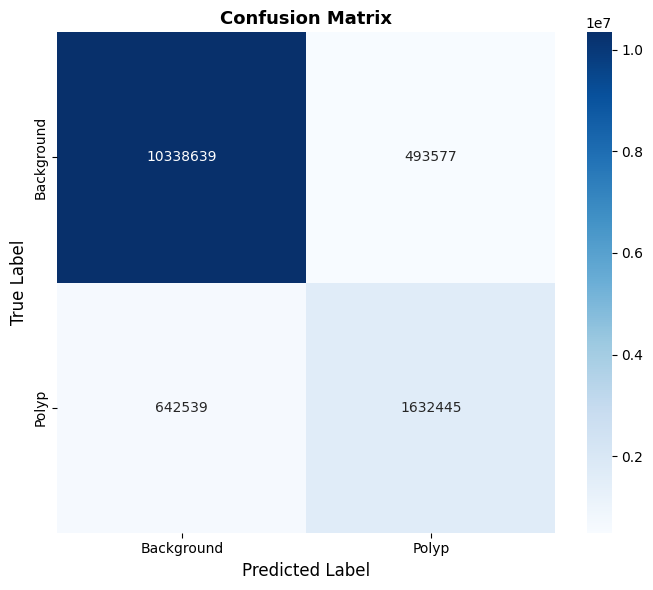

   True Negatives : 10,338,639
   True Positives : 1,632,445
   False Positives: 493,577
   False Negatives: 642,539


In [18]:

# ────────────────────────────────────────────────────────────────
# CONFUSION MATRIX (UPDATED SAFE VERSION)
# ────────────────────────────────────────────────────────────────

cm = confusion_matrix(val_targets, val_preds, labels=[0, 1])  # ← FIX 1

tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Background", "Polyp"],
    yticklabels=["Background", "Polyp"],
    ax=ax
)

ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")  # ← FIX 2
plt.show()

print(f"   True Negatives : {tn:,}")
print(f"   True Positives : {tp:,}")
print(f"   False Positives: {fp:,}")
print(f"   False Negatives: {fn:,}")


In [19]:
# ════════════════════════════════════════════════════════════════
# PER-SAMPLE IoU ANALYSIS (FINAL ROBUST VERSION)
# ════════════════════════════════════════════════════════════════

model.eval()
sample_ious = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        outputs = model(imgs)
        preds   = (torch.sigmoid(outputs) > 0.5).float()

        for i in range(preds.size(0)):

            pred_i  = preds[i]
            mask_i  = masks[i]

            intersection = (pred_i * mask_i).sum()
            union        = (pred_i + mask_i).sum() - intersection

            # Handle empty-mask case properly
            if union == 0:
                iou_val = 1.0
            else:
                iou_val = (intersection / union).item()

            sample_ious.append(iou_val)

sample_ious = np.array(sample_ious)

print("Per-Sample IoU Statistics (Validation Set)")
print(f"   Mean IoU : {sample_ious.mean():.4f}")
print(f"   Std  IoU : {sample_ious.std():.4f} ")
print(f"   Min  IoU : {sample_ious.min():.4f} ")
print(f"   Max  IoU : {sample_ious.max():.4f} ")



Per-Sample IoU Statistics (Validation Set)
   Mean IoU : 0.6172
   Std  IoU : 0.2170 
   Min  IoU : 0.0737 
   Max  IoU : 0.9550 


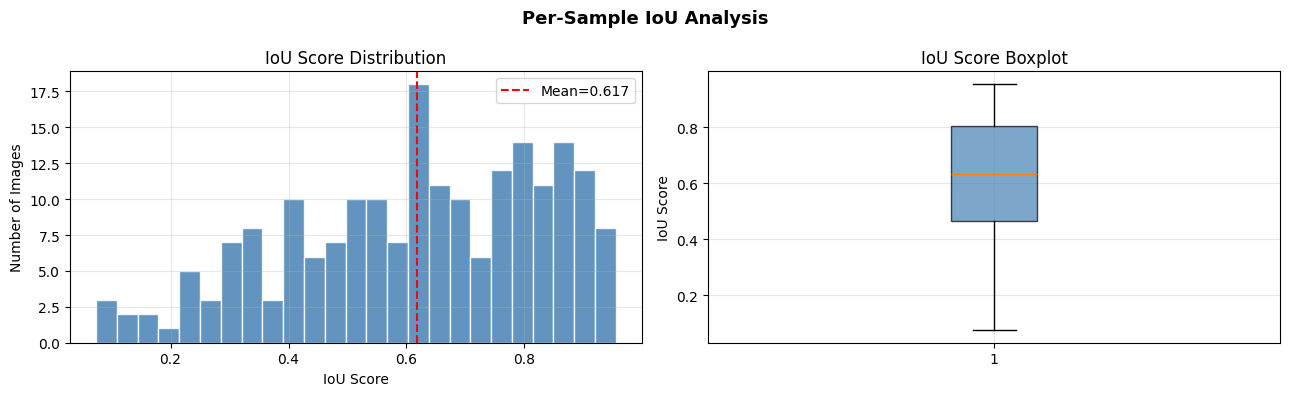

 IoU distribution saved to iou_distribution.png


In [21]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sample_ious, bins=25, color="steelblue",
             edgecolor="white", alpha=0.85)
axes[0].axvline(sample_ious.mean(), color="red",
                linestyle="--",
                label=f"Mean={sample_ious.mean():.3f}")
axes[0].set_xlabel("IoU Score")
axes[0].set_ylabel("Number of Images")
axes[0].set_title("IoU Score Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(sample_ious, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_ylabel("IoU Score")
axes[1].set_title("IoU Score Boxplot")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Per-Sample IoU Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("iou_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(" IoU distribution saved to iou_distribution.png")

In [22]:

# ════════════════════════════════════════════════════════════════
# SAVE METRICS TO TEXT FILE (FINAL PROFESSIONAL VERSION)
# ════════════════════════════════════════════════════════════════

import datetime

MODEL_PATH = "/kaggle/working/unet_seg_final_model_1.pth"
REPORT_PATH = "/kaggle/working/metrics_report.txt"

timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

report_lines = [
    "POLYP SEGMENTATION — METRICS REPORT",
    "=" * 50,
    f"Generated on : {timestamp}",
    f"Model File   : {os.path.basename(MODEL_PATH)}",
    f"Architecture : U-Net (256x256 input)",
    f"Loss         : Dice (0.8) + BCE (0.2), pos_weight=3.0",
    "=" * 50,
    "SEGMENTATION METRICS (Validation Set):",
    f"  Precision  : {precision:.4f}",
    f"  Recall     : {recall:.4f}",
    f"  F1-Score   : {f1:.4f}",
    f"  IoU        : {iou:.4f}",
    f"  Accuracy   : {acc:.4f}",
    "=" * 50,
    "PER-SAMPLE IoU STATISTICS:",
    f"  Mean IoU   : {sample_ious.mean():.4f}",
    f"  Std  IoU   : {sample_ious.std():.4f}",
    f"  Min  IoU   : {sample_ious.min():.4f}",
    f"  Max  IoU   : {sample_ious.max():.4f}",
    "=" * 50,
    "CONFUSION MATRIX:",
    f"  True Positives  (TP): {tp:,}",
    f"  True Negatives  (TN): {tn:,}",
    f"  False Positives (FP): {fp:,}",
    f"  False Negatives (FN): {fn:,}",
    "=" * 50,
]

with open(REPORT_PATH, "w") as f:
    f.write("\n".join(report_lines))

print("\n".join(report_lines))
print(f"\n Metrics report saved to {REPORT_PATH}")

POLYP SEGMENTATION — METRICS REPORT
Generated on : 2026-03-02 07:27:15
Model File   : unet_seg_final_model_1.pth
Architecture : U-Net (256x256 input)
Loss         : Dice (0.8) + BCE (0.2), pos_weight=3.0
SEGMENTATION METRICS (Validation Set):
  Precision  : 0.7678
  Recall     : 0.7176
  F1-Score   : 0.7419
  IoU        : 0.5896
  Accuracy   : 0.9133
PER-SAMPLE IoU STATISTICS:
  Mean IoU   : 0.6172
  Std  IoU   : 0.2170
  Min  IoU   : 0.0737
  Max  IoU   : 0.9550
CONFUSION MATRIX:
  True Positives  (TP): 1,632,445
  True Negatives  (TN): 10,338,639
  False Positives (FP): 493,577
  False Negatives (FN): 642,539

 Metrics report saved to /kaggle/working/metrics_report.txt


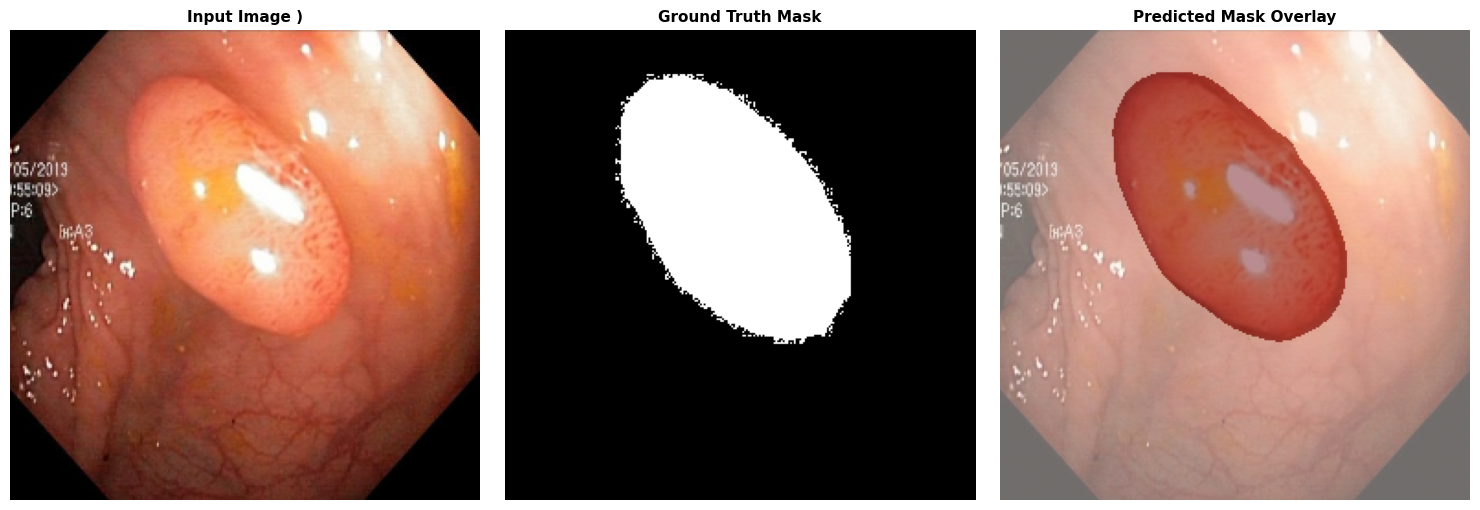

 Visualization saved 


In [23]:
# ════════════════════════════════════════════════════════════════
# SAMPLE PREDICTION VISUALIZATION (SELECTED SAMPLES: 1, 2, 5)
# ════════════════════════════════════════════════════════════════
#
# Shows specific sample indices from validation set.
# SELECTED_INDICES = [0, 1, 4] → images 1, 2, 5 (0-indexed)
#
# Change SELECTED_INDICES to any indices you want to visualize.
# Max index = len(val_dataset) - 1
# ════════════════════════════════════════════════════════════════

SELECTED_INDICES = [4]   # ← image 1, 2, 5 (0-indexed)

model.eval()

# Collect only the specific samples we want
selected_imgs, selected_masks, selected_preds = [], [], []

with torch.no_grad():
    for idx in SELECTED_INDICES:
        img, mask = val_dataset[idx]

        img_t  = img.unsqueeze(0).to(device)   # [1, 3, H, W]
        mask_t = mask.unsqueeze(0).to(device)  # [1, 1, H, W]

        output = model(img_t)
        pred   = (torch.sigmoid(output) > 0.5).float()

        selected_imgs.append(img_t[0])
        selected_masks.append(mask_t[0])
        selected_preds.append(pred[0])

num_show = len(SELECTED_INDICES)
fig, axes = plt.subplots(num_show, 3, figsize=(15, 5 * num_show))

if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_show):
    img_disp = denormalize(selected_imgs[i])
    mask_np  = selected_masks[i].cpu().squeeze().numpy()
    pred_np  = selected_preds[i].cpu().squeeze().numpy()

    # Per-image IoU
    intersection = (pred_np * mask_np).sum()
    union        = (pred_np + mask_np).sum() - intersection
    img_iou      = 1.0 if union == 0 else intersection / union

    # Column 1: Input
    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title(f"Input Image )",
                          fontsize=11, fontweight="bold")
    axes[i, 0].set_xlabel(f"IoU: {img_iou:.3f}",
                           fontsize=10,
                           color="green" if img_iou > 0.5 else "red")
    axes[i, 0].axis("off")

    # Column 2: Ground Truth
    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask", fontsize=11, fontweight="bold")
    axes[i, 1].axis("off")

    # Column 3: Prediction Overlay
    axes[i, 2].imshow(img_disp)
    axes[i, 2].imshow(pred_np, cmap="Reds", alpha=0.45)
    axes[i, 2].set_title("Predicted Mask Overlay", fontsize=11, fontweight="bold")
    axes[i, 2].axis("off")


plt.tight_layout()
plt.savefig("segmentation_results_selected.png", dpi=300, bbox_inches="tight")
plt.show()

print(f" Visualization saved ")